In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import ArtistAnimation
import sys
sys.path.append('..')
import sourse
import glob
from scipy import signal
from scipy import signal as scipysignal
from matplotlib.colors import LinearSegmentedColormap
plt.rcParams["font.size"] = 15

(176, 1)


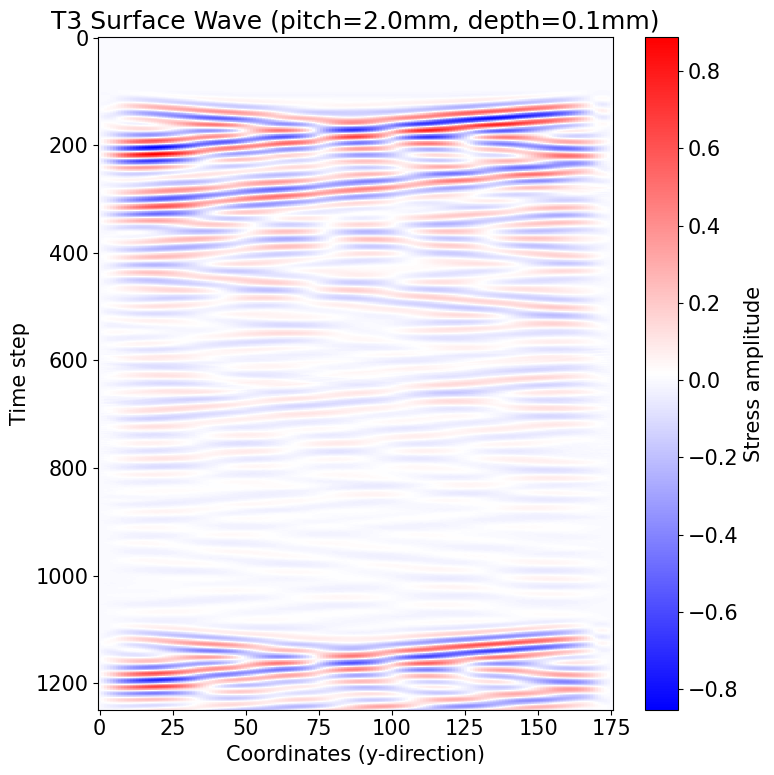

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
plt.rcParams["font.size"] = 15

# パラメータ設定
pitch = 200
depth = 10
data_dir = "C:\\Users\\manat\\project2\\surface_wave_data"

# T3_yokoデータの読み込み
# 最初のファイルを読み込んで初期化
data = pd.DataFrame(np.loadtxt(f"{data_dir}\\mannaka2_pitch{pitch}_depth{depth}_T3_yoko_t0_1799_2tonaji.csv"))
print(data.shape)
# 残りのファイルを結合
for i in range(1, 1250):  # t0は既に読み込んでいるので1から開始
    filename = f"{data_dir}\\mannaka2_pitch{pitch}_depth{depth}_T3_yoko_t{i*10}_1799_2tonaji.csv"
    data = pd.concat([data, pd.DataFrame(np.loadtxt(filename))], axis=1)

# 描画
fig, ax = plt.subplots(1, 1, figsize=(8, 8))

# T3_yokoの2次元プロット（時間 vs 位置）
img = ax.imshow(data.T, interpolation='nearest', cmap="bwr", aspect='auto')
ax.set_title(f"T3 Surface Wave (pitch={pitch/100}mm, depth={depth/100}mm)")
ax.set_xlabel("Coordinates (y-direction)")
ax.set_ylabel("Time step")

# カラーバー追加
cbar = fig.colorbar(img, ax=ax)
cbar.set_label("Stress amplitude")

plt.tight_layout()
plt.show()

ファイルチェック中...

有効ファイル数: 1391
無効ファイル数: 0

データサイズ: (176, 1391)


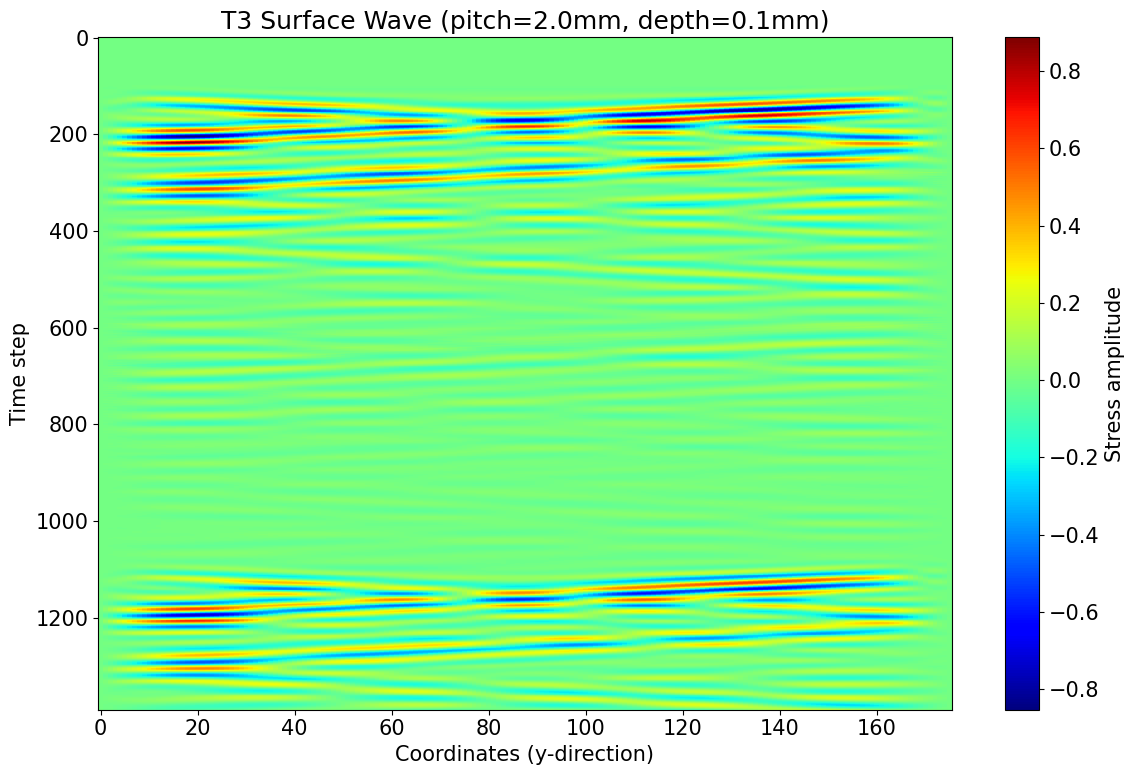

In [40]:
import os
# パラメータ設定
pitch = 200
depth = 10
data_dir = "C:\\Users\\manat\\project2\\surface_wave_data"

# ファイルの存在と読み込み可能性をチェック
print("ファイルチェック中...")
valid_files = []
invalid_files = []

for i in range(0, 1391):
    filename = f"{data_dir}\\mannaka2_pitch{pitch}_depth{depth}_T3_yoko_t{i*10}_1799.csv"
    
    if not os.path.exists(filename):
        print(f"存在しない: t{i*10}")
        continue
    
    try:
        # ファイルサイズチェック
        size = os.path.getsize(filename)
        if size == 0:
            print(f"空ファイル: t{i*10}")
            invalid_files.append(i)
            continue
            
        # 読み込みテスト
        test_data = np.loadtxt(filename)
        valid_files.append(i)
    except Exception as e:
        print(f"読み込みエラー t{i*10}: {str(e)[:50]}")
        invalid_files.append(i)

print(f"\n有効ファイル数: {len(valid_files)}")
print(f"無効ファイル数: {len(invalid_files)}")

if len(valid_files) > 0:
    # 最初の有効なファイルで初期化
    first_file = f"{data_dir}\\mannaka2_pitch{pitch}_depth{depth}_T3_yoko_t{valid_files[0]*10}_1799.csv"
    data = pd.DataFrame(np.loadtxt(first_file))
    
    # 残りの有効なファイルを結合
    for i in valid_files[1:]:
        filename = f"{data_dir}\\mannaka2_pitch{pitch}_depth{depth}_T3_yoko_t{i*10}_1799.csv"
        data = pd.concat([data, pd.DataFrame(np.loadtxt(filename))], axis=1)
    
    print(f"\nデータサイズ: {data.shape}")
    
    # 描画
    fig, ax = plt.subplots(1, 1, figsize=(12, 8))
    
    img = ax.imshow(data.T, interpolation='nearest', cmap="jet", aspect='auto')
    ax.set_title(f"T3 Surface Wave (pitch={pitch/100}mm, depth={depth/100}mm)")
    ax.set_xlabel("Coordinates (y-direction)")
    ax.set_ylabel("Time step")
    
    cbar = fig.colorbar(img, ax=ax)
    cbar.set_label("Stress amplitude")
    
    plt.tight_layout()
    plt.show()
else:
    print("有効なファイルが見つかりませんでした")

In [41]:
print(sourse.dt)

7.1282897372711e-10


1.25     1735～1836   991～1092     0.1と0.2

2.00     1799～1975   999～1175　1399～1575　　0.1と0.2と0.3

In [42]:
print(10*sourse.dt*100 + sourse.dt*4000)

3.56414486863555e-06


In [43]:
pitch = 200
depth = 10
start_point = 1799
end_point = 1975

data_point1 = 75
data_point2 = 5


In [44]:
#  T3横方向の表面波 
data = pd.DataFrame(np.loadtxt(f"I:\\waveform_2d2\\mannaka2_pitch{pitch}_depth{depth}_T3_yoko_t0_1799.csv"))
#  T1縦方向の表面波 
data2 = pd.DataFrame(np.loadtxt(f"I:\\waveform_2d2\\mannaka2_pitch{pitch}_depth{depth}_T1_tate_t0_1799.csv"))
data3 = pd.DataFrame(np.loadtxt(f"I:\\waveform_2d2\\mannaka2_pitch{pitch}_depth{depth}_T1_tate_1774_t0_1799.csv"))

data_probe = np.loadtxt(f"C:\\Users\\Fujii Kotaro\\project1\\mannaka2_pitch{pitch}_depth{depth}.csv")


data7 = np.array(data_probe[8922:])
print(len(data7))
data7 = signal.decimate(data7, 10)


for i in range(1390):
    data = pd.concat([data, pd.DataFrame(np.loadtxt(f"I:\\waveform_2d2\\mannaka2_pitch{pitch}_depth{depth}_T3_yoko_t{i*10}_1799.csv"))], axis=1)
    data2 = pd.concat([data2, pd.DataFrame(np.loadtxt(f"I:\\waveform_2d2\\mannaka2_pitch{pitch}_depth{depth}_T1_tate_t{i*10}_1799.csv"))], axis=1)
    data3 = pd.concat([data3, pd.DataFrame(np.loadtxt(f"I:\\waveform_2d2\\mannaka2_pitch{pitch}_depth{depth}_T1_tate_1774_t{i*10}_1799.csv"))], axis=1)

data_vector = data.iloc[data_point1, :]
data2_vector = data2.iloc[data_point2, :]
data3_vector = data3.iloc[data_point2, :]
#  列名の変更
data_vector.index = np.arange(0, 1391)
data2_vector.index = np.arange(0, 1391)
data3_vector.index = np.arange(0, 1391)


FileNotFoundError: I:\waveform_2d2\mannaka2_pitch200_depth10_T3_yoko_t0_1799.csv not found.

NameError: name 'data2' is not defined

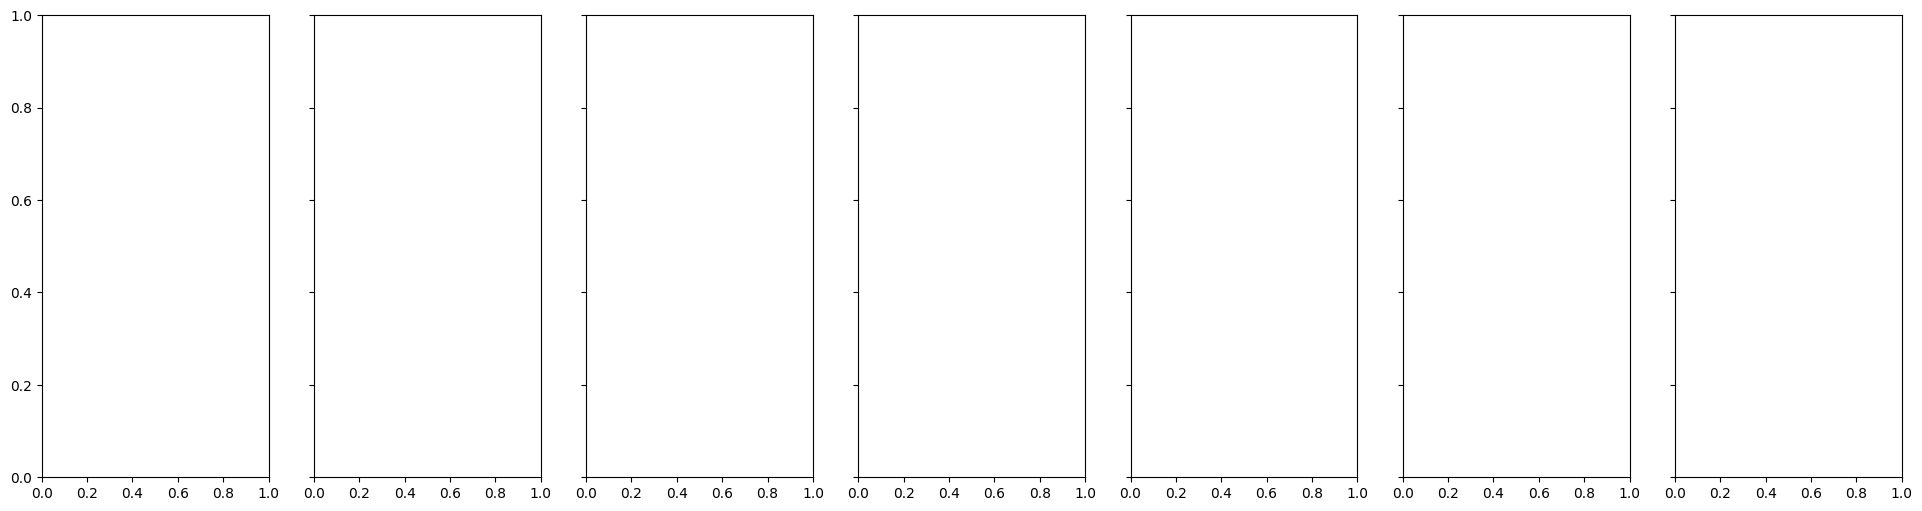

In [ ]:
fig, ax = plt.subplots(1, 7, figsize=(24, 6), sharey=True)  # 縦4つから横4つに変更
time = np.arange(len(data2.T))
# グラフ1
img = ax[0].imshow(data2.T, interpolation='nearest', cmap="jet", aspect='auto', vmin=-3.0, vmax=3.0)  # .T で転置
ax[0].set_title(f"position={start_point} l-wave")
ax[0].set_xlabel("coordinates")  # y軸ラベルがx軸ラベルに
ax[0].set_ylabel("time")         # x軸ラベルがy軸ラベルに


# グラフ2
img2 = ax[1].imshow(data.T, interpolation='nearest', cmap="jet", aspect='auto')  # .T で転置
ax[1].tick_params(left=False, labelleft=False)
ax[1].set_title(f"position={start_point+1}~{end_point-1} surface")
ax[1].set_xlabel("coordinates")


# グラフ3
img3 = ax[2].imshow(data3.T, interpolation='nearest', cmap="jet", aspect='auto', vmin=-3.0, vmax=3.0)  # .T で転置
ax[2].tick_params(left=False, labelleft=False)
ax[2].set_title(f"postion={end_point} l-wave")
ax[2].set_xlabel("coordinates")

# グラフ5
img5 = ax[3].plot(np.pad(data7, (0, 1391-len(data7)), mode="constant", constant_values=np.nan), time)  
ax[3].tick_params(left=False, labelleft=False)  # x軸の代わりにy軸のティックを非表示
ax[3].set_title("position=probe l-wave")
ax[3].set_xlabel("Amplitude")
ax[3].set_xlim(-1.6, 1.5)

# グラフ6
img6 = ax[5].plot(data_vector, time)  
ax[5].tick_params(left=False, labelleft=False)  # x軸の代わりにy軸のティックを非表示
ax[5].set_title(f"position={data_point1} l-wave")
ax[5].set_xlabel("Amplitude")
ax[5].set_xlim(-0.7, 0.7)
# グラフ7
img7 = ax[4].plot(data2_vector, np.arange(0, 1391))  
ax[4].tick_params(left=False, labelleft=False)  # x軸の代わりにy軸のティックを非表示
ax[4].set_title(f"position=({start_point}, {data_point2}) l-wave")
ax[4].set_xlabel("Amplitude")
ax[4].set_xlim(-3.0, 3.0)

# グラフ7
img7 = ax[6].plot(data3_vector, np.arange(0, 1391))  
ax[6].tick_params(left=False, labelleft=False)  # x軸の代わりにy軸のティックを非表示
ax[6].set_title(f"position=({end_point}, {data_point2}) l-wave")
ax[6].set_xlabel("Amplitude")
ax[6].set_xlim(-3.0, 3.0)
fig.colorbar(img)
fig.colorbar(img2)
fig.colorbar(img3)
plt.tight_layout()
plt.show()